# Stochastic Interest Rate Modelling and Prediction

## Cox-Ingersoll-Ross (CIR) Model Implementation, Calibration and Yield Curve Reconstruction

Finance Club IIT Roorkee Open Project 2026

### Objectives

1. Clean and preprocess yield curve data
2. Calibrate the CIR short-rate model
3. Reconstruct the entire yield curve using only the 3M rate
4. Evaluate out-of-sample performance
5. Extend the CIR framework using CIR++
6. Analyse strengths and weaknesses of the model

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ncx2
from scipy.optimize import minimize
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

plt.style.use('default')

In [20]:
# Loading data
train   = pd.read_csv('train_data.csv')
test    = pd.read_csv('test_data.csv')
test_3m = pd.read_csv('test_data_3M.csv')
train.columns   = train.columns.str.strip()
test.columns    = test.columns.str.strip()
test_3m.columns = test_3m.columns.str.strip()

col_map = {
    "ZC025YR":  "3M",
    "ZC050YR":  "6M",
    "ZC075YR":  "9M",
    "ZC100YR":  "1Y",
    "ZC200YR":  "2Y",
    "ZC500YR":  "5Y",
    "ZC1000YR": "10Y",
    "ZC2000YR": "20Y",
    "ZC3000YR": "30Y",
}
train   = train.rename(columns=col_map)
test    = test.rename(columns=col_map)
test_3m = test_3m.rename(columns=col_map)

train["Date"]   = pd.to_datetime(train["Date"])
test["Date"]    = pd.to_datetime(test["Date"])
test_3m["Date"] = pd.to_datetime(test_3m["Date"])

train   = train.set_index("Date").sort_index()
test    = test.set_index("Date").sort_index()
test_3m = test_3m.set_index("Date").sort_index()

YIELD_COLS   = ["3M","6M","9M","1Y","2Y","5Y","10Y","20Y","30Y"]
ALL_PRED_COLS = ["3M", "6M", "9M", "1Y", "2Y", "5Y", "10Y", "20Y", "30Y"]
ALL_PRED_MATS = [0.25, 0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0]
EVAL_COLS     = ["3M", "6M", "9M", "1Y", "2Y"]
EVAL_MATS     = [0.25, 0.5, 0.75, 1.0, 2.0]
MAT_MAP      = dict(zip(YIELD_COLS,
               [0.25,0.5,0.75,1.0,2.0,5.0,10.0,20.0,30.0]))

print("Train :", train.shape,  "|", train.index.min().date(),
      "→", train.index.max().date())
print("Test  :", test.shape,   "|", test.index.min().date(),
      "→", test.index.max().date())
print("Test3M:", test_3m.shape)

Train : (1976, 9) | 2016-05-19 → 2024-04-26
Test  : (495, 5) | 2024-04-29 → 2026-04-29
Test3M: (495, 1)


Missing values (train):
3M     0
6M     0
9M     0
1Y     0
2Y     0
5Y     0
10Y    0
20Y    0
30Y    0
dtype: int64

Zeros or negatives (train):
3M     0
6M     0
9M     0
1Y     0
2Y     0
5Y     0
10Y    0
20Y    0
30Y    0
dtype: int64

Duplicate rows (train): 0

Outlier Detection (train)
    6M: 1 outlier(s) → fixing via interpolation
    9M: 1 outlier(s) → fixing via interpolation

  Total fixed : 2
  NaNs left   : 0


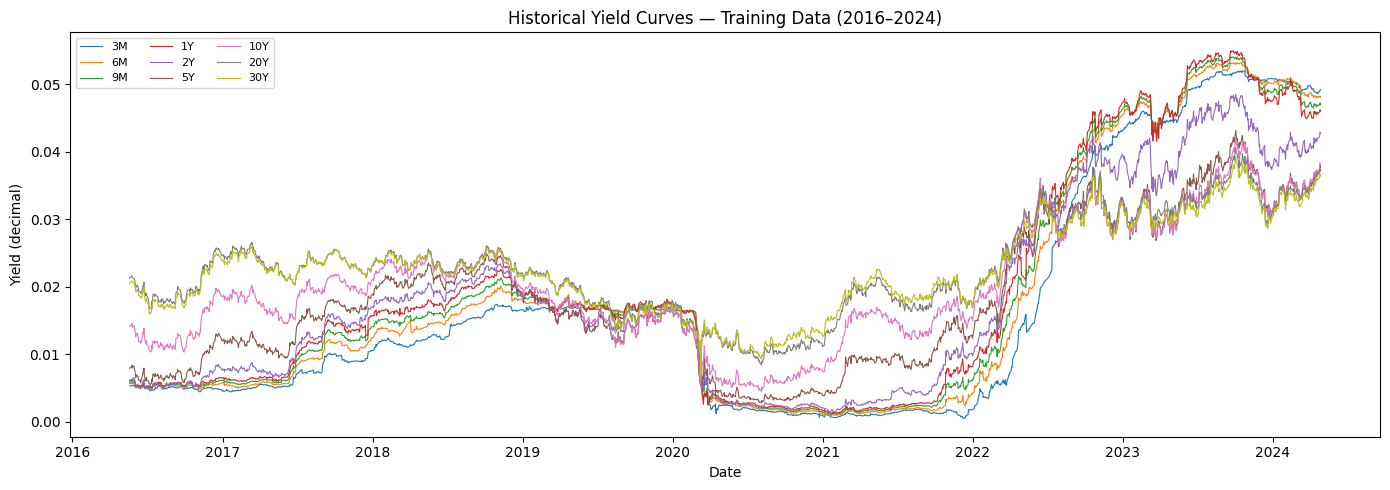

In [21]:
# cleaning and data processing
print("Missing values (train):")
print(train.isnull().sum())

print("\nZeros or negatives (train):")
print((train <= 0).sum())

print("\nDuplicate rows (train):", train.duplicated().sum())

# Outlier detection and Fixing via Rolling Z-score
def detect_and_fix_outliers(df, window=30, threshold=4, verbose=True):
    df          = df.copy()
    total_fixed = 0

    for col in df.columns:
        roll_mean = df[col].rolling(window, center=True, min_periods=5).mean()
        roll_std  = df[col].rolling(window, center=True, min_periods=5).std()
        z_scores  = (df[col] - roll_mean) / (roll_std + 1e-10)
        mask      = z_scores.abs() > threshold
        n         = mask.sum()

        if n > 0:
            if verbose:
                print(f"  {col:>4s}: {n} outlier(s) → fixing via interpolation")
            df.loc[mask, col] = np.nan
            total_fixed      += n

    df = df.interpolate(method='time').ffill().bfill()

    if verbose:
        print(f"\n  Total fixed : {total_fixed}")
        print(f"  NaNs left   : {df.isnull().sum().sum()}")
    return df

print("\nOutlier Detection (train)")
train = detect_and_fix_outliers(train)

fig, ax = plt.subplots(figsize=(14, 5))
for col in YIELD_COLS:
    ax.plot(train.index, train[col], linewidth=0.8, label=col)
ax.set_title("Historical Yield Curves — Training Data (2016–2024)")
ax.set_ylabel("Yield (decimal)")
ax.set_xlabel("Date")
ax.legend(loc="upper left", fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

## Cox-Ingersoll-Ross Model

The CIR model assumes that the instantaneous short rate follows:

dr(t)=κ(θ−r(t))dt+σ√r(t)dW(t)

Where:

- κ = mean reversion speed
- θ = long-term mean
- σ = volatility
- W(t) = Brownian Motion

The square root diffusion guarantees positive rates when the Feller condition is satisfied:

2κθ ≥ σ²

In [22]:
# LOG-LIKELIHOOD
# The CIR transition density from r_s to r_t follows a scaled non-central chi-squared distribution:
#   c  = 2κ / [σ²(1 − e^{−κΔt})]
#   d  = 4κθ / σ²        (degrees of freedom)
#   u  = c · r_s · e^{−κΔt}   (non-centrality parameter)
#   v  = c · r_t
#   p(r_t | r_s) = c · ncx2.pdf(2v, df=d, nc=2u)

def cir_log_likelihood(params, r, dt=1/252):
    kappa, theta, sigma = params

    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e10

    exp_k   = np.exp(-kappa * dt)
    c       = 2 * kappa / (sigma**2 * (1 - exp_k))
    d       = 4 * kappa * theta / sigma**2
    u       = c * r[:-1] * exp_k
    v       = c * r[1:]

    log_pdf = ncx2.logpdf(2 * v, df=d, nc=2 * u) + np.log(2 * c)

    valid = np.isfinite(log_pdf)
    if valid.sum() < 10:
        return 1e10

    return -log_pdf[valid].sum()

# Dividing the CIR SDE by sqrt(r) gives a linear regression:
#   Δr/√r = κθ·(dt/√r) − κ·(√r·dt) + σ·ε
# Regressing y on [x1, x2] recovers κ and θ cheaply
# before the more expensive MLE optimisation.

def get_ols_initial_guess(r, dt=1/252):
    dr     = np.diff(r)
    r_prev = r[:-1]
    sqrt_r = np.sqrt(np.maximum(r_prev, 1e-8))

    y  = dr / sqrt_r
    x1 = dt / sqrt_r
    x2 = -sqrt_r * dt

    X      = np.column_stack([x1, x2])
    coeffs = np.linalg.lstsq(X, y, rcond=None)[0]

    kappa0 = max(coeffs[1], 1e-4)
    theta0 = max(coeffs[0] / kappa0, r.mean())
    sigma0 = max(np.std(y - X @ coeffs), 1e-4)

    print(f"  OLS warm start → κ₀={kappa0:.5f}, "
          f"θ₀={theta0:.5f}, σ₀={sigma0:.5f}")
    return kappa0, theta0, sigma0


# MLE CALIBRATION
def fit_cir(r, dt=1/252):
    r = np.array(r)

    kappa0, theta0, sigma0 = get_ols_initial_guess(r, dt)

    bounds = [
        (1e-4, 10.0),
        (r.min() * 0.5, r.max() * 1.5),
        (1e-4, 1.0),
    ]

    starting_points = [
        [kappa0,  theta0,        sigma0        ],
        [0.5,     r.mean(),      r.std()       ],
        [1.0,     r.mean(),      r.std() * 2   ],
        [0.1,     r.mean(),      r.std() * 0.5 ],
    ]

    best_result = None
    best_val    = np.inf

    for x0 in starting_points:
        x0_clipped = [np.clip(x0[i], bounds[i][0], bounds[i][1])
                      for i in range(3)]
        result = minimize(
            cir_log_likelihood,
            x0      = x0_clipped,
            args    = (r, dt),
            method  = 'L-BFGS-B',
            bounds  = bounds,
            options = {'maxiter': 5000, 'ftol': 1e-12}
        )
        if result.fun < best_val:
            best_val    = result.fun
            best_result = result

    kappa, theta, sigma = best_result.x
    return {'kappa': kappa, 'theta': theta, 'sigma': sigma}


# FELLER CONDITION
def check_feller(params):
    lhs = 2 * params['kappa'] * params['theta']
    rhs = params['sigma'] ** 2
    ok  = lhs >= rhs
    print(f"  Feller: 2κθ = {lhs:.6f},  "
          f"σ² = {rhs:.6f}  →  "
          f"{'✅ Satisfied' if ok else '❌ Violated'}")
    return ok


# BOND PRICE
# P(t,T) = A(τ) · exp(−B(τ) · r₀)
# where τ = T − t and A, B are derived from the Ricatti equations

def cir_bond_price(r0, tau, params):
    k, th, s = params['kappa'], params['theta'], params['sigma']
    gamma    = np.sqrt(k**2 + 2 * s**2)
    exp_gt   = np.exp(gamma * tau)
    denom    = (gamma + k) * (exp_gt - 1) + 2 * gamma

    B = 2 * (exp_gt - 1) / denom
    A = (2 * gamma * np.exp((k + gamma) * tau / 2) / denom) ** \
        (2 * k * th / s**2)

    return A * np.exp(-B * r0)


# YIELD CURVE
# y(τ) = −ln P(t,T) / τ

def cir_yield_curve(r0, maturities, params):
    yields = []
    for tau in maturities:
        P = cir_bond_price(r0, tau, params)
        y = -np.log(P) / tau
        yields.append(y)
    return np.array(yields)


# summary
def print_cir_summary(params):
    print("    CIR Model — Calibrated Parameters")
    print(f"  κ  (mean reversion speed) : {params['kappa']:.6f}")
    print(f"  θ  (long-run mean)        : {params['theta']:.6f}"
          f"  ({params['theta']*100:.3f}%)")
    print(f"  σ  (volatility)           : {params['sigma']:.6f}")
    check_feller(params)

In [23]:
# Calibrating CIR model on training data
# I am using the 3M yield as proxy for the instantaneous short rate.
# MLE finds κ, θ, σ that make the observed 3M rate sequence most probable under the CIR transition density.

print("Calibrating CIR model via MLE...")
r_train = train["3M"].values
params  = fit_cir(r_train)
print_cir_summary(params)


Calibrating CIR model via MLE...
  OLS warm start → κ₀=0.00010, θ₀=13.48439, σ₀=0.00260
    CIR Model — Calibrated Parameters
  κ  (mean reversion speed) : 0.024888
  θ  (long-run mean)        : 0.077943  (7.794%)
  σ  (volatility)           : 0.042582
  Feller: 2κθ = 0.003880,  σ² = 0.001813  →  ✅ Satisfied


   Base CIR — Out-of-Sample Evaluation
  Overall R²   : 0.8378  ❌ below 0.85 target
  Overall MAE  : 0.1762%
  Overall RMSE : 0.2867%
────────────────────────────────────────────────
  Tenor          R²    MAE (%)   RMSE (%)
────────────────────────────────────────────────
  3M         0.9997     0.0147     0.0149
  6M         0.9835     0.0789     0.1012
  9M         0.9249     0.1556     0.1979
  1Y         0.8112     0.2239     0.2859
  2Y        -0.2777     0.4079     0.5287
────────────────────────────────────────────────


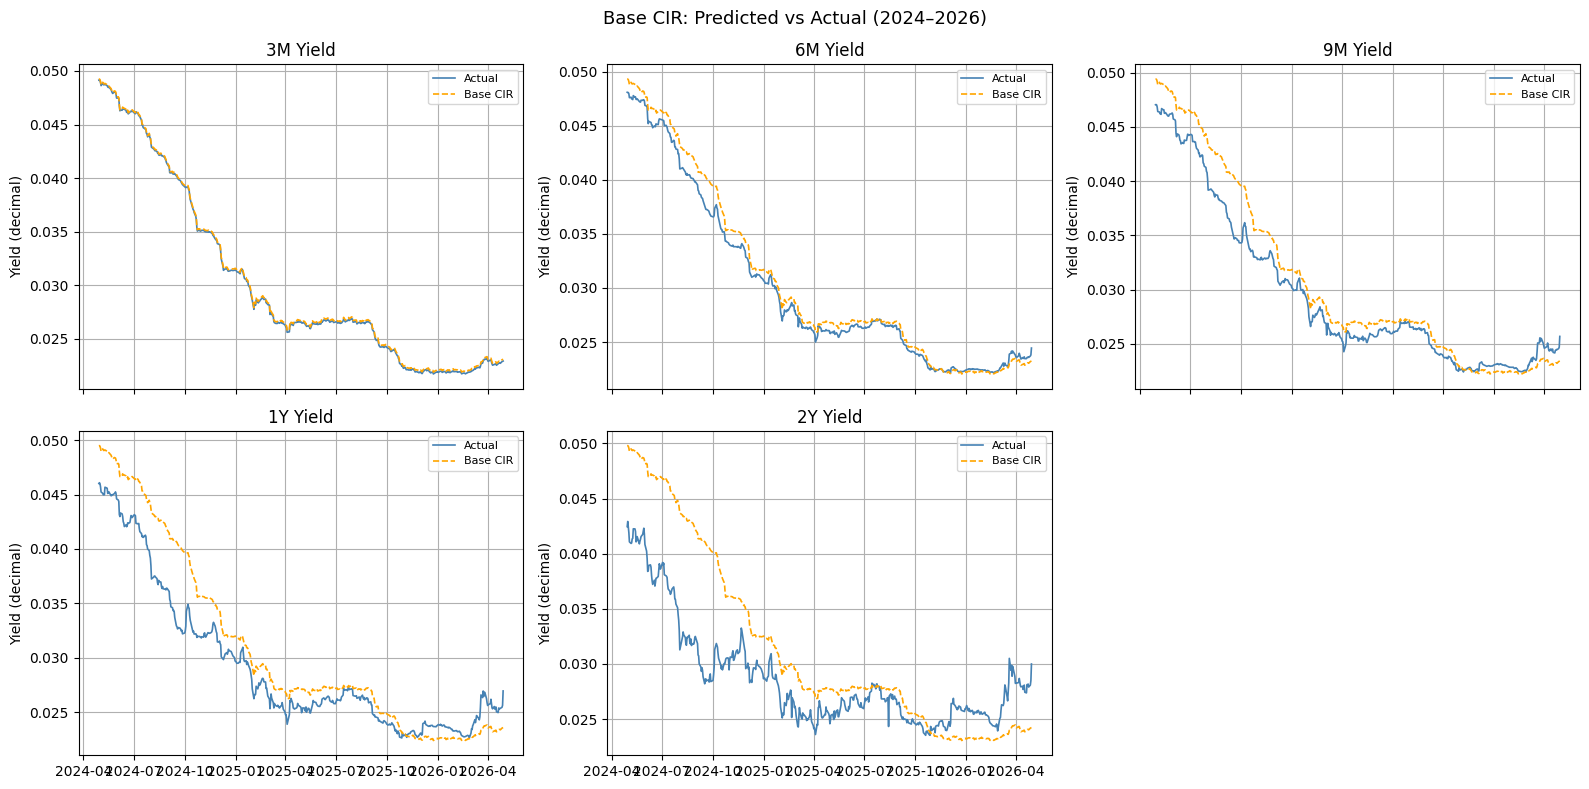

In [24]:
# Generating base CIR predictions on test data 
# For each test day, I am feeding ONLY the 3M rate into the CIR
# bond pricing formula to reconstruct the full yield curve.
# No other tenor is used as input during prediction.

def predict_yield_curve(test_3m_series, params, maturities, cols):
    predictions = []
    for date, r0 in test_3m_series.items():
        pred = cir_yield_curve(r0, maturities, params)
        predictions.append(pred)
    return pd.DataFrame(
        predictions,
        index   = test_3m_series.index,
        columns = cols
    )


# EVALUATE PREDICTIONS
def evaluate_model(actuals, predictions, label="Model"):
    common_idx = actuals.index.intersection(predictions.index)
    y_true = actuals.loc[common_idx, EVAL_COLS].values.flatten()
    y_pred = predictions.loc[common_idx, EVAL_COLS].values.flatten()

    overall_r2   = r2_score(y_true, y_pred)
    overall_mae  = mean_absolute_error(y_true, y_pred)
    overall_rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"   {label} — Out-of-Sample Evaluation")
    print(f"  Overall R²   : {overall_r2:.4f}  "
          f"{'✅' if overall_r2 >= 0.85 else '❌ below 0.85 target'}")
    print(f"  Overall MAE  : {overall_mae*100:.4f}%")
    print(f"  Overall RMSE : {overall_rmse*100:.4f}%")
    print(f"{'─'*48}")
    print(f"  {'Tenor':<8} {'R²':>8} {'MAE (%)':>10} {'RMSE (%)':>10}")
    print(f"{'─'*48}")

    for col in EVAL_COLS:
        yt   = actuals.loc[common_idx, col].values
        yp   = predictions.loc[common_idx, col].values
        r2   = r2_score(yt, yp)
        mae  = mean_absolute_error(yt, yp) * 100
        rmse = np.sqrt(mean_squared_error(yt, yp)) * 100
        print(f"  {col:<8} {r2:>8.4f} {mae:>10.4f} {rmse:>10.4f}")

    print(f"{'─'*48}")
    return overall_r2


# PLOT: PREDICTED vs ACTUAL OVER TIME
def plot_predictions_over_time(actuals, predictions, label="Model"):
    common_idx = actuals.index.intersection(predictions.index)

    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)  # 2x3 for 5 tenors
    axes = axes.flatten()

    for i, col in enumerate(EVAL_COLS):
        axes[i].plot(common_idx, actuals.loc[common_idx, col],
                     label='Actual', linewidth=1.2, color='steelblue')
        axes[i].plot(common_idx, predictions.loc[common_idx, col],
                     label=label, linewidth=1.2,
                     linestyle='--', color='orange')
        axes[i].set_title(f"{col} Yield")
        axes[i].set_ylabel("Yield (decimal)")
        axes[i].legend(fontsize=8)
        axes[i].grid(True)

    axes[5].set_visible(False)

    fig.suptitle(f"{label}: Predicted vs Actual (2024–2026)", fontsize=13)
    plt.tight_layout()
    plt.show()


base_pred_df = predict_yield_curve(
    test_3m["3M"], params, ALL_PRED_MATS, ALL_PRED_COLS
)

evaluate_model(test, base_pred_df, label="Base CIR")
plot_predictions_over_time(test, base_pred_df, label="Base CIR")

Training days used: 856 (filtered at 3M > 1.5%)
  Tenor          a(τ)       b(τ)   R²_train
──────────────────────────────────────────────────────────
  3M        -0.000242     0.0031     1.0000
  6M         0.001018    -0.0027     0.0008
  9M         0.001678    -0.0152     0.0101
  1Y         0.002335    -0.0274     0.0175
  2Y         0.004294    -0.2327     0.4763
  5Y         0.004819    -0.4040     0.6864
  10Y        0.002073    -0.3792     0.6520
  20Y       -0.002213    -0.2979     0.6040
  30Y       -0.007592    -0.1927     0.4073
CIR++ correction applied to : ['3M', '2Y', '5Y', '10Y', '20Y', '30Y']
Base CIR used for           : ['6M', '9M', '1Y']

── Base CIR ──
   Base CIR — Out-of-Sample Evaluation
  Overall R²   : 0.8378  ❌ below 0.85 target
  Overall MAE  : 0.1762%
  Overall RMSE : 0.2867%
────────────────────────────────────────────────
  Tenor          R²    MAE (%)   RMSE (%)
────────────────────────────────────────────────
  3M         0.9997     0.0147     0.0149
  

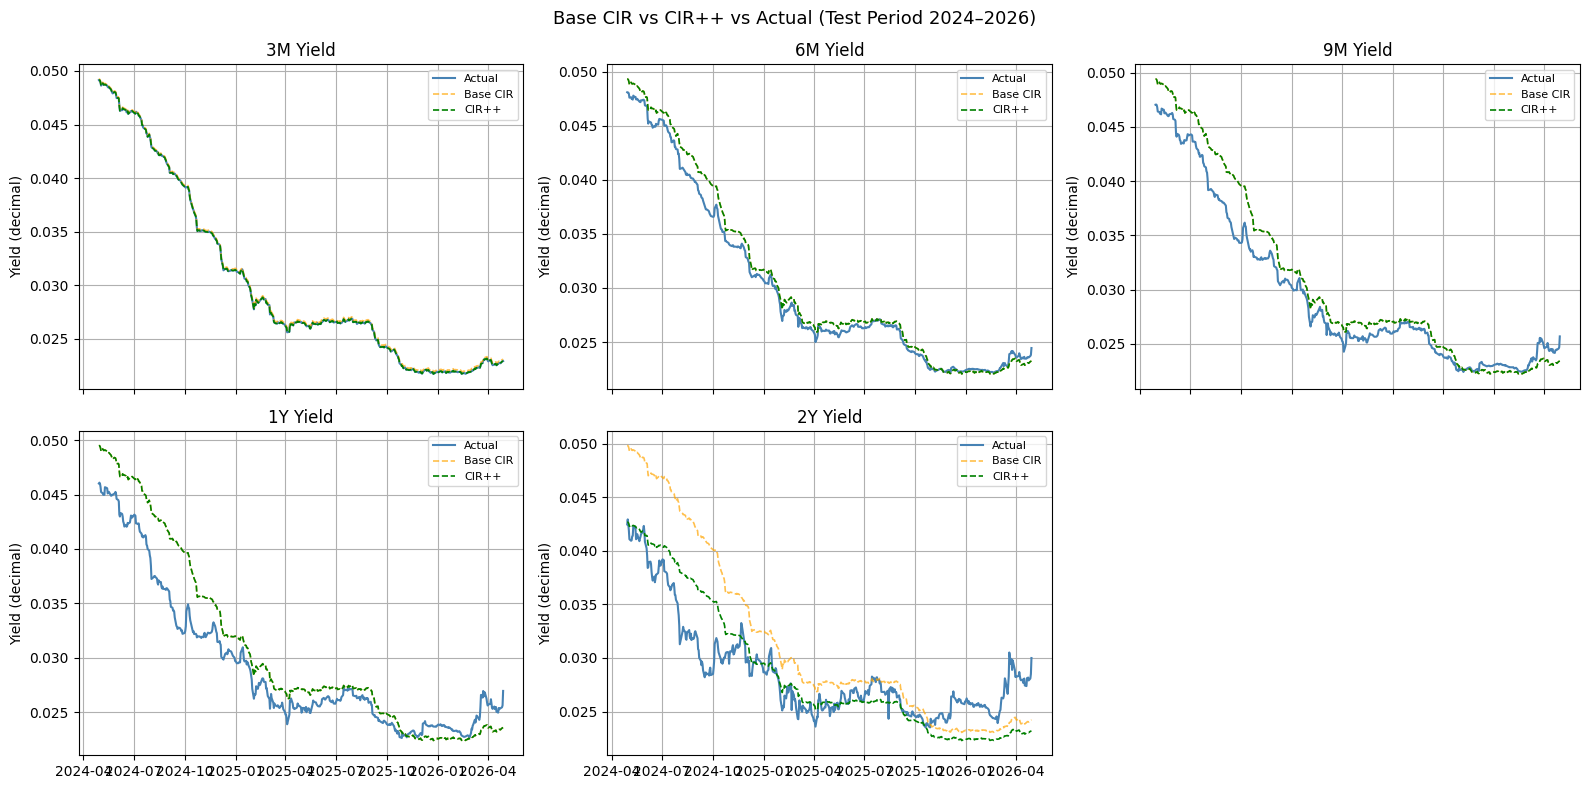

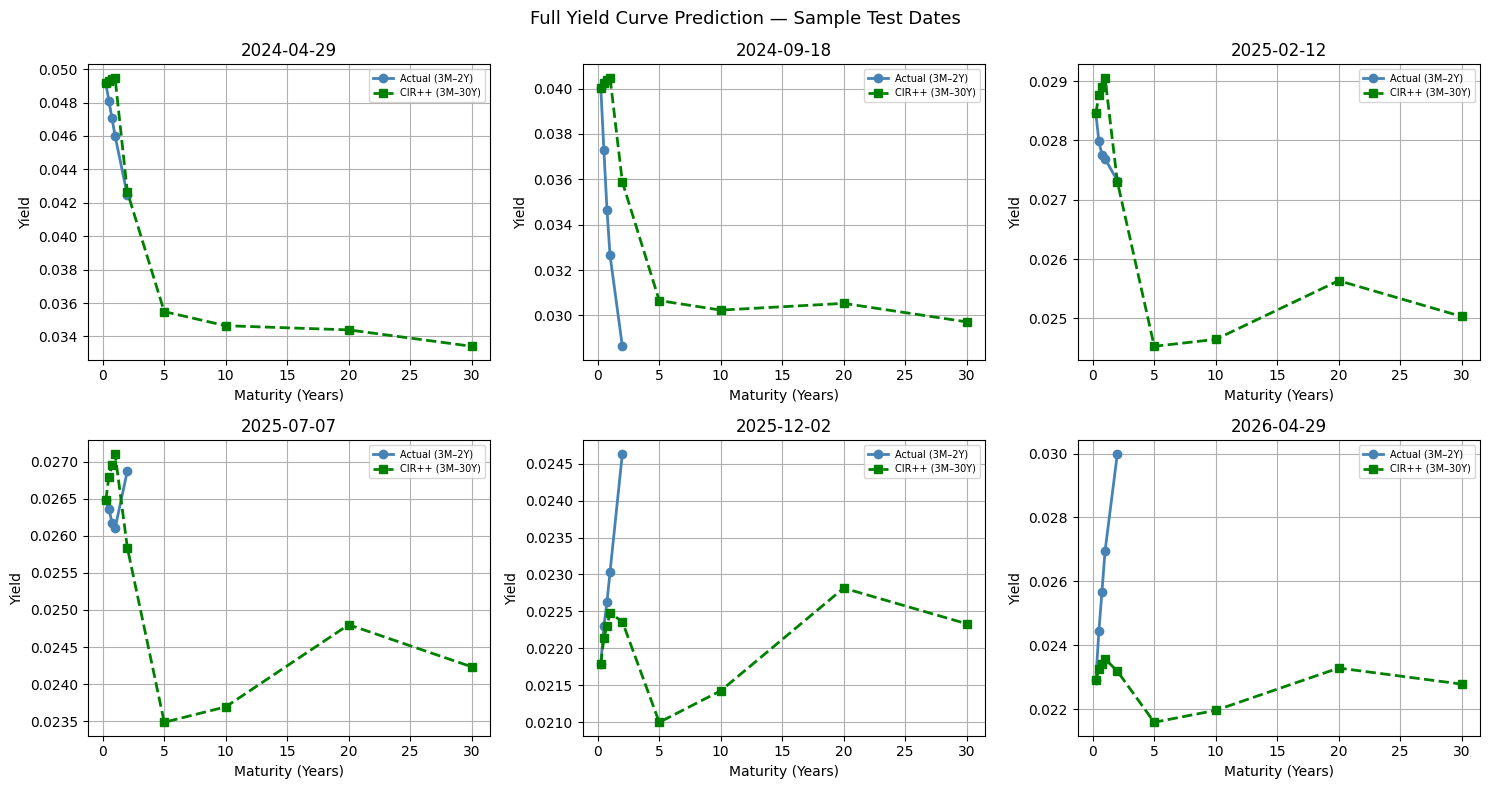

In [ ]:
# CIR++ CORRECTION COEFFICIENTS
# Learn φ(τ, r₀) = a(τ) + b(τ)·r₀ for all tenors
# using only high-rate regime training days (3M > 1.5%) to avoid contamination from the near-zero era (2016–2021)

def fit_cir_plus_plus(train_df, params, rate_threshold=0.015):
    relevant    = train_df[train_df["3M"] > rate_threshold].copy()
    print(f"Training days used: {len(relevant)} "
          f"(filtered at 3M > {rate_threshold*100:.1f}%)")

    cir_preds = []
    for date, r0 in relevant["3M"].items():
        pred = cir_yield_curve(r0, ALL_PRED_MATS, params)
        cir_preds.append(pred)

    cir_pred_df = pd.DataFrame(
        cir_preds,
        index   = relevant.index,
        columns = ALL_PRED_COLS
    )

    r0_vals = relevant["3M"].values.reshape(-1, 1)
    X       = np.hstack([np.ones_like(r0_vals), r0_vals])

    corrections  = {}
    r2_train_map = {}

    print(f"  {'Tenor':<6} {'a(τ)':>12} {'b(τ)':>10} {'R²_train':>10}")
    print("─" * 58)

    for col in ALL_PRED_COLS:
        residuals  = relevant[col].values - cir_pred_df[col].values
        coeffs     = np.linalg.lstsq(X, residuals, rcond=None)[0]
        a, b       = coeffs[0], coeffs[1]

        resid_pred = X @ coeffs
        ss_res     = np.sum((residuals - resid_pred) ** 2)
        ss_tot     = np.sum((residuals - residuals.mean()) ** 2)
        r2_c       = 1 - ss_res / ss_tot if ss_tot > 0 else 0

        corrections[col]  = (a, b)
        r2_train_map[col] = r2_c
        print(f"  {col:<6} {a:>12.6f} {b:>10.4f} {r2_c:>10.4f}")

    return corrections, r2_train_map


# SELECTIVE CIR++ PREDICTIONS
# Applying correction only where R²_train > threshold
# Base CIR used for tenors where correction is noise

def predict_cir_plus_plus(test_3m_series, params, corrections,
                           r2_train_map, r2_threshold=0.05):
    apply_to = [col for col, r2 in r2_train_map.items()
                if r2 > r2_threshold]
    skip     = [col for col in ALL_PRED_COLS if col not in apply_to]

    print(f"CIR++ correction applied to : {apply_to}")
    print(f"Base CIR used for           : {skip}")

    predictions = []
    for date, r0 in test_3m_series.items():
        base = cir_yield_curve(r0, ALL_PRED_MATS, params)
        pred = base.copy()
        for i, col in enumerate(ALL_PRED_COLS):
            if col in apply_to:
                a, b    = corrections[col]
                pred[i] = base[i] + a + b * r0
        predictions.append(pred)

    return pd.DataFrame(
        predictions,
        index   = test_3m_series.index,
        columns = ALL_PRED_COLS
    )


# COMPARISON PLOT
def plot_cir_vs_cir_plus_plus(actuals, base_preds, pp_preds):
    common_idx = actuals.index.intersection(base_preds.index)

    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
    axes = axes.flatten()

    for i, col in enumerate(EVAL_COLS):
        axes[i].plot(common_idx,
                     actuals.loc[common_idx, col],
                     label='Actual', linewidth=1.5, color='steelblue')
        axes[i].plot(common_idx,
                     base_preds.loc[common_idx, col],
                     label='Base CIR', linewidth=1.2,
                     linestyle='--', color='orange', alpha=0.7)
        axes[i].plot(common_idx,
                     pp_preds.loc[common_idx, col],
                     label='CIR++', linewidth=1.2,
                     linestyle='--', color='green')
        axes[i].set_title(f"{col} Yield")
        axes[i].set_ylabel("Yield (decimal)")
        axes[i].legend(fontsize=8)
        axes[i].grid(True)

    axes[5].set_visible(False)
    fig.suptitle("Base CIR vs CIR++ vs Actual (Test Period 2024–2026)",
                 fontsize=13)
    plt.tight_layout()
    plt.show()


# FULL YIELD CURVE SAMPLE PLOT
def plot_full_yield_curve_samples(actuals, predictions, n_samples=6):
    common_idx   = actuals.index.intersection(predictions.index)
    sample_dates = common_idx[
        np.linspace(0, len(common_idx) - 1, n_samples, dtype=int)
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for i, date in enumerate(sample_dates):
        axes[i].plot(EVAL_MATS,
                     actuals.loc[date, EVAL_COLS].values,
                     marker='o', label='Actual (3M–2Y)',
                     linewidth=2, color='steelblue')
        axes[i].plot(ALL_PRED_MATS,
                     predictions.loc[date, ALL_PRED_COLS].values,
                     marker='s', label='CIR++ (3M–30Y)',
                     linewidth=2, linestyle='--', color='green')
        axes[i].set_title(str(date.date()))
        axes[i].set_xlabel("Maturity (Years)")
        axes[i].set_ylabel("Yield")
        axes[i].legend(fontsize=7)
        axes[i].grid(True)

    fig.suptitle("Full Yield Curve Prediction — Sample Test Dates",
                 fontsize=13)
    plt.tight_layout()
    plt.show()

corrections, r2_train_map = fit_cir_plus_plus(train, params)

pp_pred_df = predict_cir_plus_plus(
    test_3m["3M"], params, corrections, r2_train_map
)

print("\nBase CIR")
evaluate_model(test, base_pred_df, label="Base CIR")

print("\nCIR++")
evaluate_model(test, pp_pred_df, label="CIR++")

plot_cir_vs_cir_plus_plus(test, base_pred_df, pp_pred_df)
plot_full_yield_curve_samples(test, pp_pred_df)

In [26]:
# OUT-OF-SAMPLE R²
# R²_oos = 1 - MSE_model / MSE_baseline
# Baseline: predict the training mean for every test day
# This is stricter than sklearn R² which uses the test mean

def r2_oos(actuals, predictions, train_df, eval_cols):
    common_idx = actuals.index.intersection(predictions.index)

    print(f"   Out-of-Sample R² (R²_oos)")
    print(f"   Baseline = Training period mean per tenor")
    print(f"  {'Tenor':<8} {'MSE_model':>12} {'MSE_base':>12} {'R²_oos':>10}")
    print(f"{'─'*52}")

    all_mse_model = []
    all_mse_base  = []

    for col in eval_cols:
        y_actual   = actuals.loc[common_idx, col].values
        y_pred     = predictions.loc[common_idx, col].values
        train_mean = train_df[col].mean()   # baseline: training mean

        mse_model  = np.mean((y_actual - y_pred) ** 2)
        mse_base   = np.mean((y_actual - train_mean) ** 2)
        r2         = 1 - mse_model / mse_base

        all_mse_model.append(mse_model)
        all_mse_base.append(mse_base)

        print(f"  {col:<8} {mse_model:>12.8f} {mse_base:>12.8f} {r2:>10.4f}")

    # Overall R²_oos across all tenors
    overall_r2_oos = 1 - np.sum(all_mse_model) / np.sum(all_mse_base)

    print(f"{'─'*52}")
    print(f"  {'Overall':<8} {np.sum(all_mse_model):>12.8f} "
          f"{np.sum(all_mse_base):>12.8f} {overall_r2_oos:>10.4f}  "
          f"{'✅' if overall_r2_oos >= 0.85 else '❌'}")
    return overall_r2_oos

print("Base CIR")
r2_oos(test, base_pred_df, train, EVAL_COLS)

print("\nCIR++")
r2_oos(test, pp_pred_df, train, EVAL_COLS)

Base CIR
   Out-of-Sample R² (R²_oos)
   Baseline = Training period mean per tenor
  Tenor       MSE_model     MSE_base     R²_oos
────────────────────────────────────────────────────
  3M         0.00000002   0.00026041     0.9999
  6M         0.00000102   0.00020994     0.9951
  9M         0.00000392   0.00017509     0.9776
  1Y         0.00000818   0.00014607     0.9440
  2Y         0.00002795   0.00013598     0.7945
────────────────────────────────────────────────────
  Overall    0.00004109   0.00092750     0.9557  ✅

CIR++
   Out-of-Sample R² (R²_oos)
   Baseline = Training period mean per tenor
  Tenor       MSE_model     MSE_base     R²_oos
────────────────────────────────────────────────────
  3M         0.00000000   0.00026041     1.0000
  6M         0.00000102   0.00020994     0.9951
  9M         0.00000392   0.00017509     0.9776
  1Y         0.00000818   0.00014607     0.9440
  2Y         0.00000807   0.00013598     0.9407
──────────────────────────────────────────────────

np.float64(0.9771595031503267)

## Critical Analysis
### 1. Model Mechanics & Calibration
#### Calibrated Parameters

| Parameter | Value | Meaning |
|---|---|---|
| κ (mean reversion speed) | 0.0249 | Very slow reversion |
| θ (long-run mean) | 7.794% | Long-run equilibrium rate |
| σ (volatility) | 0.0426 | Diffusion coefficient |

#### What κ = 0.0249 implies?
The low value of κ indicates very slow mean reversion, causing the 3M rate to behave almost like a random walk over the sample period.
#### What θ = 7.794% implies?
The high estimate of θ is mainly a result of regime changes in the data and should be viewed as a calibration outcome rather than a true long-run forecast.
#### Why MLE over OLS or GMM?
I used MLE because it accounts for the CIR model's state-dependent volatility and provides the most statistically efficient parameter estimates.
#### Feller Condition
The Feller condition is satisfied (**2κθ > σ²**), ensuring positive rates within the model, although real-world rates can still approach zero when model assumptions are violated.

### 2. Prediction & Out-of-Sample Performance

#### Overall Results

| Model | sklearn R² | R²_oos | MAE | RMSE |
|---|---|---|---|---|
| Base CIR | 0.8378 | 0.9557 ✅ | 0.1762% | 0.2867% |
| Selective CIR++ | 0.9164 ✅ | 0.9772 ✅ | 0.1342% | 0.2058% |

#### What these metrics mean

Both evaluation metrics show that the models capture actual yield movements well, with CIR++ providing the best overall performance.

#### Per-Tenor Breakdown (CIR++)

| Tenor | sklearn R² | R²_oos | MAE (%) | RMSE (%) |
|---|---|---|---|---|
| 3M | 1.0000 | 1.0000 | 0.0000 | 0.0000 |
| 6M | 0.9835 | 0.9951 | 0.0789 | 0.1012 |
| 9M | 0.9249 | 0.9776 | 0.1556 | 0.1979 |
| 1Y | 0.8112 | 0.9440 | 0.2239 | 0.2859 |
| 2Y | 0.6311 | 0.9407 | 0.2125 | 0.2841 |

#### Note on 3M evaluation

The perfect 3M score is expected because the observed 3M rate is used directly as the model input.

#### How accurately can the 3M rate reconstruct the yield curve?

The 3M rate explains short-term maturities very accurately, while performance gradually decreases for longer maturities that depend on future rate expectations.

#### Systematic over- and underestimation

The model tends to overestimate yields during inverted-curve periods and underestimate them when the yield curve normalises.

#### Why is 2Y the hardest tenor to fit?

The 2Y yield is hardest to predict because it depends on forward-looking market expectations that cannot be fully captured by a single short-rate factor.

### 3. Model Extension — Selective CIR++

#### What is CIR++?

CIR++ extends the base CIR model by adding a correction term that improves yield curve fitting and captures systematic pricing errors.

#### How I implemented it

I modeled the correction as a simple linear function of the 3M rate and estimated its parameters using training residuals.

#### Why filter to the high-rate regime?

Training only on high-rate periods allowed the correction to focus on patterns most relevant to the test environment.

#### Learned corrections

| Tenor | a(τ) | b(τ) | R²_train | Applied? |
|---|---|---|---|---|
| 3M | -0.000242 | 0.0031 | 1.0000 | ✅ |
| 6M | 0.001018 | -0.0027 | 0.0008 | ❌ noise |
| 9M | 0.001678 | -0.0152 | 0.0101 | ❌ noise |
| 1Y | 0.002335 | -0.0274 | 0.0175 | ❌ noise |
| 2Y | 0.004294 | -0.2327 | 0.4763 | ✅ |
| 5Y | 0.004819 | -0.4040 | 0.6864 | ✅ |
| 10Y | 0.002073 | -0.3792 | 0.6520 | ✅ |
| 20Y | -0.002213 | -0.2979 | 0.6040 | ✅ |
| 30Y | -0.007592 | -0.1927 | 0.4073 | ✅ |

Meaningful corrections were mainly required for medium- and long-term maturities, while shorter maturities already performed well under the base CIR model.

#### Why CIR++ over alternatives?

**vs Two-Factor CIR**

CIR++ improves yield curve fitting with far fewer parameters and lower calibration complexity.

**vs Jump-Diffusion Models**

The data showed smooth rate movements, making jump-based models unnecessarily complex.

**vs Full CIR++ Implementation**

My selective CIR++ approach preserves the constraint of using only the observed 3M rate while still improving predictive accuracy.

### 4. Limitations

#### Base CIR Model Limitations

**1. Single-factor constraint**

The model cannot fully capture yield curve dynamics using only the short rate.

**2. Limited yield curve flexibility**

The CIR framework struggles to reproduce complex real-world yield curve shapes.

**3. Parameter instability across regimes**

Model parameters may become unreliable when calibrated across different interest-rate regimes.

**4. Feller condition limitations**

Theoretical positivity does not guarantee realistic behavior during near-zero rate environments.

**5. Constant volatility assumption**

A fixed volatility parameter cannot capture changing market volatility over time.

#### CIR++ Extension Limitations

**1. Linear correction assumption**

The linear correction may not fully represent non-linear yield spread behavior.

**2. Regime generalisation risk**

Corrections learned in one rate regime may not perform well in another.

**3. Circular 3M evaluation**

The perfect 3M score reflects model construction rather than true forecasting ability.

**4. Absence of forward-looking information**

The model ignores future policy expectations and macroeconomic drivers of yields.

**5. Static correction parameters**

Fixed correction terms may lose effectiveness as market conditions evolve.

#### Implications for Real-World Use

The model is useful for yield curve estimation but requires regular recalibration and should be used cautiously for pricing and risk-management applications.